# Image Convolution

In [2]:
import pathlib
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import PIL
from PIL import Image, ImageOps
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

import cv2

The goal in this notebook is to explore convolutions on images. The context used are fotographs of flowers that need to be preprocessed so they are easier to classify and recognise.

In [5]:
dataset_url = "http://download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = keras.utils.get_file(origin=dataset_url,
                                fname='flower_photos',
                                untar=True)

data_dir = pathlib.Path(data_dir) / "flower_photos"

for folder in data_dir.glob('[!LICENSE]*'):
    print('The', folder.name, 'folder has',
          len(list(folder.glob('*.jpg'))), 'pictures')
image_count = len(list(data_dir.glob('*/*.jpg')))
print(image_count, 'total images')

The daisy folder has 633 pictures
The dandelion folder has 898 pictures
The roses folder has 641 pictures
The tulips folder has 799 pictures
3670 total images


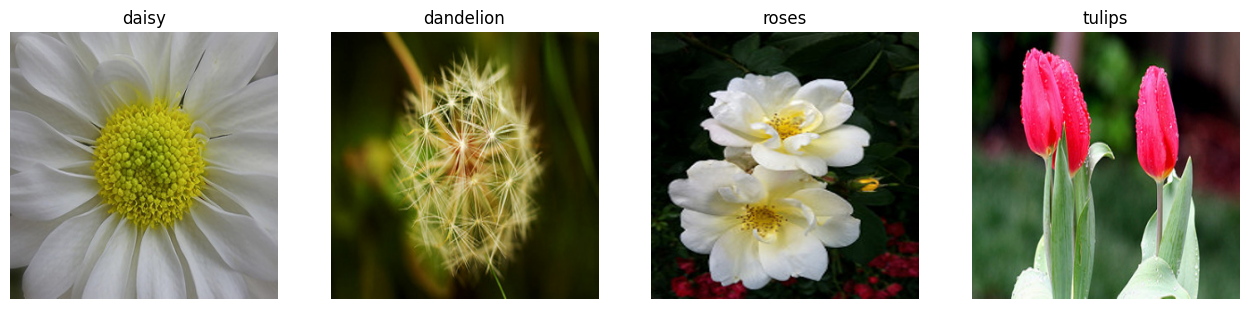

In [7]:
pics = list()
pics_arr = list()
p_class = list()

img_width = 300
img_height = 300

plt.figure(figsize=(20,5))
for idx, folder in enumerate(data_dir.glob('[!LICENSE]*')):
    cat = list(data_dir.glob(folder.name + '/*'))
    pic = PIL.Image.open(str(cat[0])).resize((img_width, img_height))
    pic_arr = np.array(pic)
    clss = folder.name
    
    plt.subplot(1,5,idx+1)
    plt.imshow(pic)
    plt.title(clss)
    plt.axis('off')
    
    pics.append(pic)
    pics_arr.append(pic_arr)
    p_class.append(clss)
    

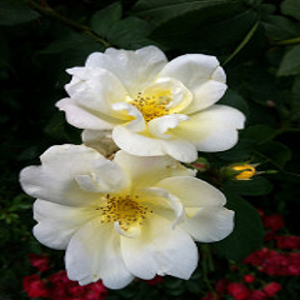

In [8]:
# Lets get an image to use for the rest of the exercises
img = pics[2]
img

## Edge Detection

Two commonly used edge detection kernels are the Prewitt Kernel and the Sobel kernel. They simply detect edges in vertical or horizontal direction. They do this by having positive weights on one side of the kernel, 0-valued weights in the middle and negative weights on the other side. This way edges in the middle will be highlighted once the kernel passes. The Sobel kernel gives more weight to the pixels directly to the side of the middle pixel.

Below we create two kernel functions using the Sobel kernel.

In [11]:
# Lets define our custom kernels for the horizontal and vertical gradients
def v_grad(shape, dtype=None):
    # Here we use a single numpy array to define our x gradient kernel
    grad = np.array([
        [1, 0, -1],
        [2, 0, -2],
        [1, 0, -1]
    ]).reshape((3, 3, 1, 1))
    # this line is quite important, we are saying we want one 3x3 kernel each for one channel of pixels (grayscale)
    
    # We check to make sure the shape of our kernel is the correct shape
    # according to the initialization of the Convolutional layer below
    assert grad.shape == shape
    return keras.backend.variable(grad, dtype='float32')

def h_grad(shape, dtype=None):
    grad = np.array([
        [1, 2, 1],
        [0, 0, 0],
        [-1, -2, -1]
        ]).reshape((3, 3, 1, 1))
    
    assert grad.shape == shape
    return keras.backend.variable(grad, dtype='float32')

Using these kernels, we can build a CNN taking in the complete image as an nxn array.

Below, we build two models, one with the horizontal edge detection kernel, and one with the vertical edge detection kernel.

In [12]:
# We define the input layer of our Neural Network
# to take in an image of 300x300 with 1 channel
# Both our models can share this, as it will not change between the two

input_layer = layers.Input(shape=(img_width, img_height, 1))

h_conv = layers.Conv2D(filters=1, # the number of kernels we are using, kernel and filter are interchangeable terms
                       kernel_size=3,
                       kernel_initializer=h_grad,
                       strides=1,
                       padding='valid')  # 'valid' means no padding

v_conv = layers.Conv2D(filters=1,
                       kernel_size=3,
                       kernel_initializer=v_grad,
                       strides=1,
                       padding='valid')


h_model = keras.Sequential([input_layer, h_conv])
v_model = keras.Sequential([input_layer, v_conv])

Since we only use a single channel here for simplicity, we need to convert our image to grayscale first.

In [19]:
gray = ImageOps.grayscale(img)

# We need to add 1 dimension to our input image which represents the batch size
# In this case, we just want to process 1 image.
input_img = np.array(gray).reshape((1, img_width, img_height, 1))

out_d = h_model.output_shape[1:]

# Pass our input image into each model, and return
# the output with a shape of (298,298,1) in variables named `Gy` and `Gx`.
Gx = h_model.predict(input_img).reshape(out_d)
Gy = v_model.predict(input_img).reshape(out_d)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


In [20]:
# Now that we have the two gradients,
# try computing our gradient magnitude G using numpy
G = np.sqrt(np.add(np.multiply(Gx, Gx), np.multiply(Gy, Gy)))

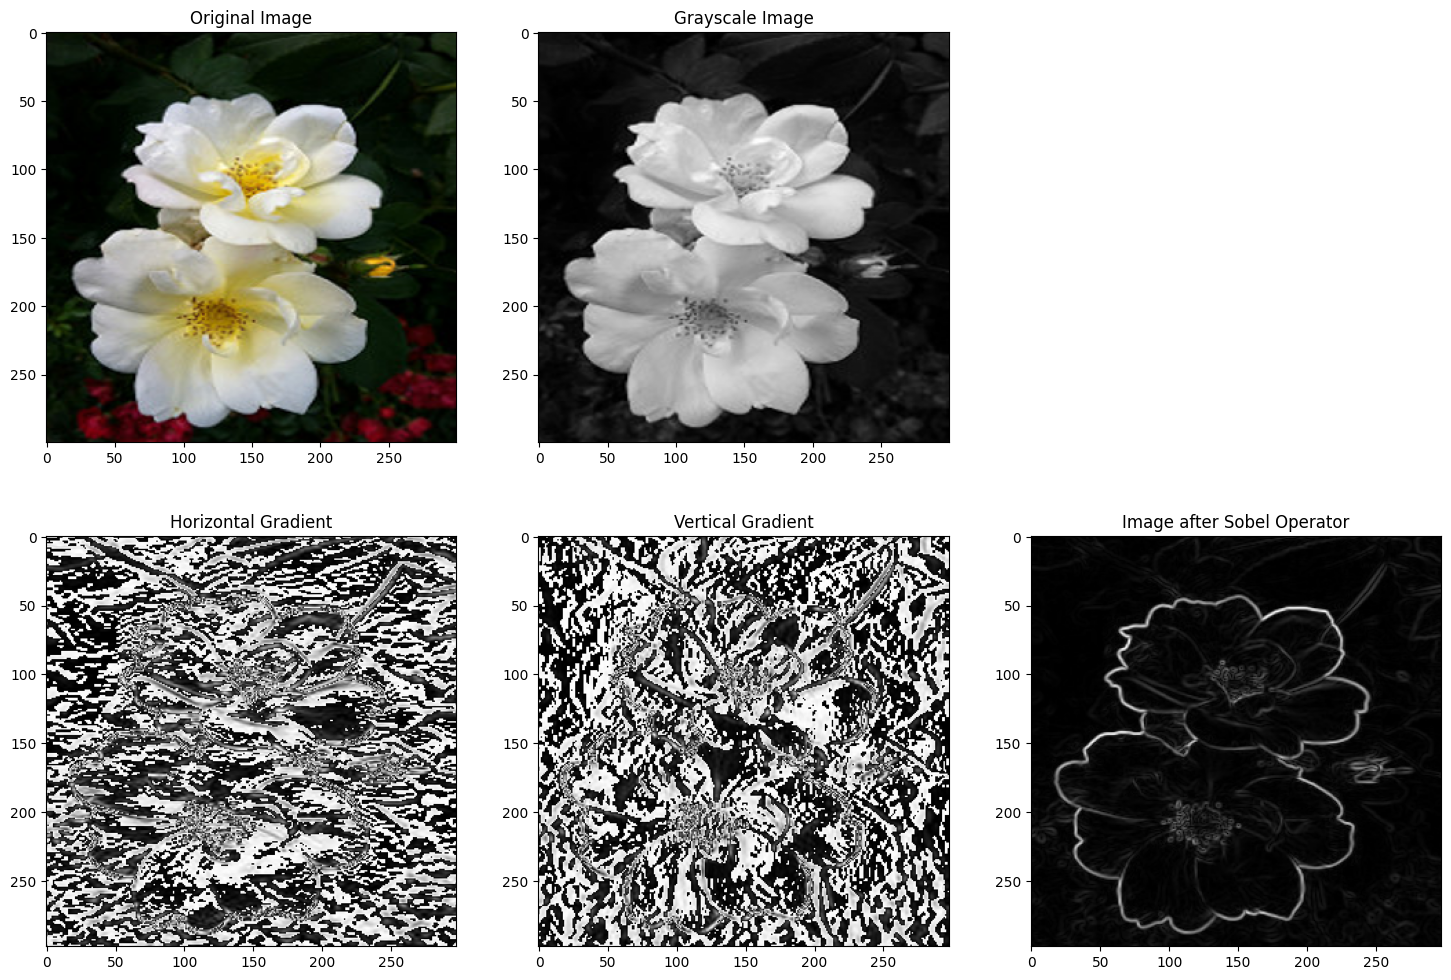

In [21]:
plt.figure(figsize=(18, 12))
plt.subplot(2, 3, 1)
plt.imshow(img)
plt.title("Original Image")
plt.subplot(2, 3, 2)
plt.imshow(gray, cmap=plt.get_cmap('gray'))
plt.title("Grayscale Image")
plt.subplot(2, 3, 4)
plt.imshow(Gx.astype('uint8'), cmap=plt.get_cmap('gray'))
plt.title("Horizontal Gradient")
plt.subplot(2, 3, 5)
plt.imshow(Gy.astype('uint8'), cmap=plt.get_cmap('gray'))
plt.title("Vertical Gradient")
plt.subplot(2, 3, 6)
plt.imshow(G, cmap=plt.get_cmap('gray'))
plt.title("Image after Sobel Operator")
plt.show()

## Corner and Blob detection

### Difference of Gaussians

This method uses two differently sized gaussian kernels to blur the image. The difference between them is a measure of the corners in the image. This makes sense since the two Gaussians take different scales into account and as such the difference between them will be correlated with the level of detail between them.

$$
\Gamma \_{\sigma\_1 ,sigma\_2 }(x,y)=
I \cdot \frac {1}{2\pi \sigma\_1^{2}} e^{ - \frac {x^{2}+y^{2}}{2\sigma\_1^{2}} } -
I \cdot \frac {1}{2\pi \sigma\_2^{2}} e^{ - \frac {x^{2}+y^{2}}{2\sigma\_2^{2}} }
$$

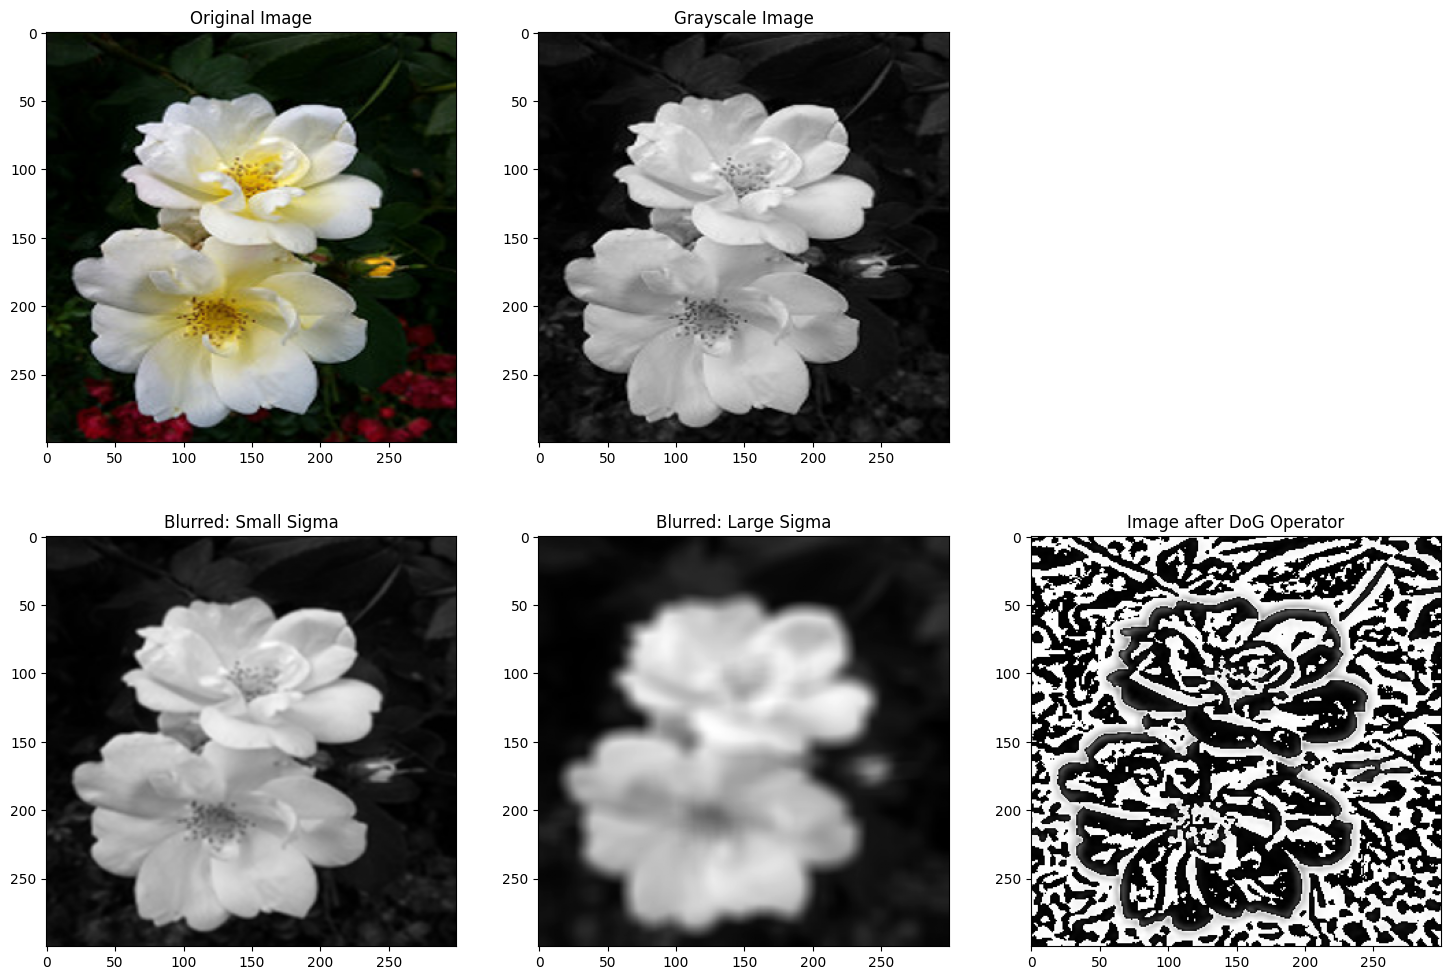

In [29]:
sigma_sm = 3
sigma_lg = 13
blurred_sm = cv2.GaussianBlur(np.array(gray), (sigma_sm, sigma_sm), sigma_sm)
blurred_lg = cv2.GaussianBlur(np.array(gray), (sigma_lg, sigma_lg), sigma_lg)

DoG = blurred_sm - blurred_lg

plt.figure(figsize=(18, 12))
plt.subplot(2, 3, 1)
plt.imshow(img)
plt.title("Original Image")
plt.subplot(2, 3, 2)
plt.imshow(gray, cmap=plt.get_cmap('gray'))
plt.title("Grayscale Image")
plt.subplot(2, 3, 4)
plt.imshow(blurred_sm.astype('uint8'), cmap=plt.get_cmap('gray'))
plt.title("Blurred: Small Sigma")
plt.subplot(2, 3, 5)
plt.imshow(blurred_lg.astype('uint8'), cmap=plt.get_cmap('gray'))
plt.title("Blurred: Large Sigma")
plt.subplot(2, 3, 6)
plt.imshow(DoG.astype('uint8'), cmap=plt.get_cmap('gray'))
plt.title("Image after DoG Operator")
plt.show()

## Other kernels

This table is from [wikipedia](https://en.wikipedia.org/wiki/Feature_(computer_vision)#Detection), which shows all the different types of methods you can use to process images and detect different features within.

|              Feature detector             | Edge | Corner | Blob | Ridge |
|:-----------------------------------------:|:----:|:------:|:----:|:-----:|
| Canny                                     |  Yes |   No   |  No  |   No  |
| Sobel                                     |  Yes |   No   |  No  |   No  |
| Harris & Stephens / Plessey               |  Yes |   Yes  |  No  |   No  |
| SUSAN                                     |  Yes |   Yes  |  No  |   No  |
| Shi & Tomasi                              |  No  |   Yes  |  No  |   No  |
| Level curve curvature                     |  No  |   Yes  |  No  |   No  |
| FAST                                      |  No  |   Yes  |  Yes |   No  |
| Laplacian of Gaussian                     |  No  |   Yes  |  Yes |   No  |
| Difference of Gaussians                   |  No  |   Yes  |  Yes |   No  |
| Determinant of Hessian                    |  No  |   Yes  |  Yes |   No  |
| Hessian strength feature measures         |  No  |   Yes  |  Yes |   No  |
| MSER                                      |  No  |   No   |  Yes |   No  |
| Principal curvature ridges                |  No  |   No   |  No  |  Yes  |
| Grey-level blobs                          |  No  |   No   |  Yes |   No  |